
--- Top 10 Longest Tracks for John Carl Misalang ---
                                     track_name                artist  duration_min
                                       Lost Boy                 Jaden      9.497883
                              I'm Getting Ready   Tasha Cobbs Leonard      8.436667
                                        Mirrors     Justin Timberlake      8.069100
What Goes Around.../...Comes Around (Interlude)     Justin Timberlake      7.476217
                             Achilles Come Down        Gang of Youths      7.035767
                           Never Let Go (Of Me)                Baltra      6.909833
          House Of Balloons / Glass Table Girls            The Weeknd      6.753550
                                           Stan                Eminem      6.735100
                                      Galvanize The Chemical Brothers      6.563550
                                    After Hours            The Weeknd      6.017100


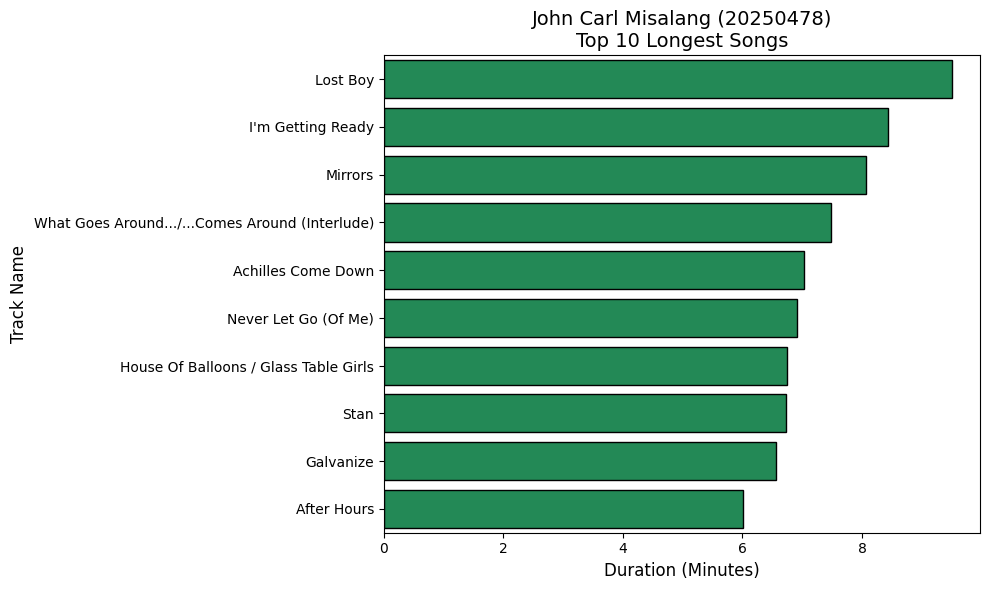

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "John Carl Misalang"
student_id = "20250478" # Replace with your actual ID
id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"

df = pd.read_csv("spotify_top_1000_tracks.csv")

color_bar = color1 

top_10_longest = df.sort_values(by='duration_min', ascending=False).head(10)

print(f"\n--- Top 10 Longest Tracks for {student_name} ---")
print(top_10_longest[['track_name', 'artist', 'duration_min']].to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    x='duration_min', 
    y='track_name', 
    data=top_10_longest, 
    color=color_bar,
    edgecolor='black'
)

plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs", fontsize=14)
plt.xlabel("Duration (Minutes)", fontsize=12)
plt.ylabel("Track Name", fontsize=12)

plt.tight_layout()
plt.show()

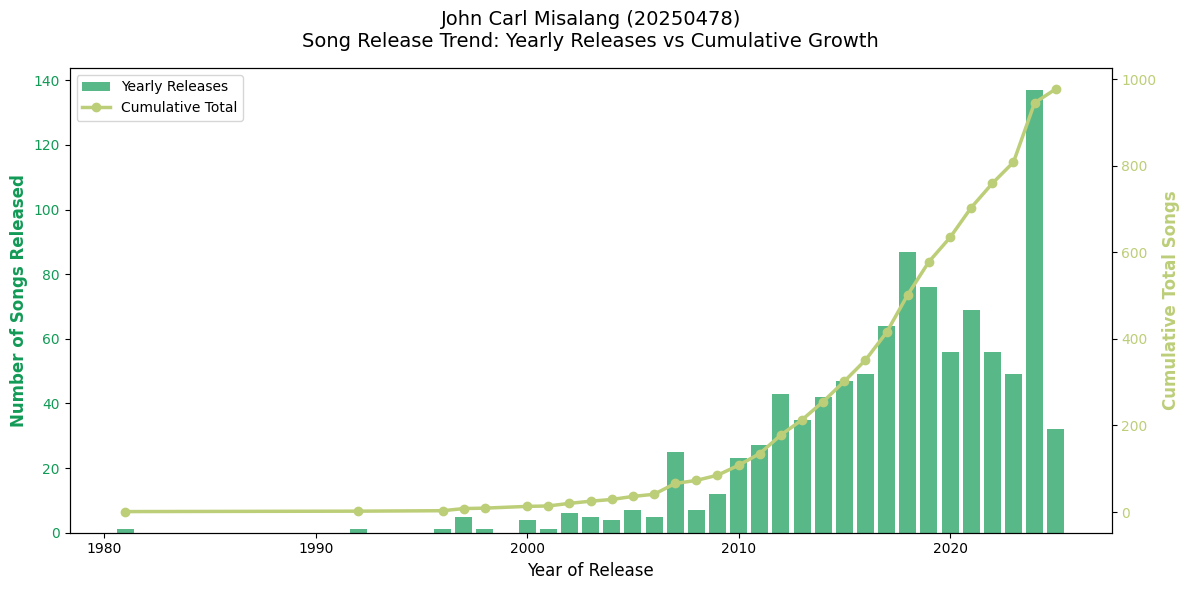

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "John Carl Misalang"
student_id = "20250478"
id_num = int(student_id[-3:])

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

color_bar = color1  
color_line = color2 

df = pd.read_csv("spotify_top_1000_tracks.csv")
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

yearly_counts = df.groupby('year').size().reset_index(name='yearly_count')

yearly_counts['cumulative_count'] = yearly_counts['yearly_count'].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(yearly_counts['year'], yearly_counts['yearly_count'], color=color_bar, alpha=0.7, label='Yearly Releases')
ax1.set_xlabel("Year of Release", fontsize=12)
ax1.set_ylabel("Number of Songs Released", color=color_bar, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_bar)

ax2 = ax1.twinx() 
ax2.plot(yearly_counts['year'], yearly_counts['cumulative_count'], color=color_line, marker='o', linewidth=2.5, label='Cumulative Total')
ax2.set_ylabel("Cumulative Total Songs", color=color_line, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)

plt.title(f"{student_name} ({student_id})\nSong Release Trend: Yearly Releases vs Cumulative Growth", fontsize=14, pad=15)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os
import webbrowser

student_name = "John Carl Misalang"
student_id = "20250478" 

colormaps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis', 'Blues', 'Reds', 'Greens', 'Purples', 'Oranges']
id_num = int(str(student_id)[-1]) if str(student_id).isdigit() else 0
cmap_color = colormaps[id_num]

df = pd.read_csv("spotify_top_1000_tracks.csv")
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

df = df.dropna(subset=['year', 'duration_min', 'popularity'])
df['year'] = df['year'].astype(int)

years = sorted(df['year'].unique())

fig, ax = plt.subplots(figsize=(10, 6))

x_min, x_max = df['duration_min'].min(), df['duration_min'].max()
y_min, y_max = df['popularity'].min(), df['popularity'].max()

def animate(i):

    ax.clear()
    
    current_year = years[i]
    
    frame_data = df[df['year'] <= current_year]
    
    ax.hexbin(
        frame_data['duration_min'], 
        frame_data['popularity'], 
        gridsize=25, 
        cmap=cmap_color, 
        mincnt=1, 
        edgecolors='black',
        linewidths=0.2
    )
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max * 1.05)
    ax.set_xlabel("Duration (Minutes)", fontsize=12)
    ax.set_ylabel("Popularity", fontsize=12)
    
    ax.set_title(f"{student_name} ({student_id})\nDensity Map: Duration vs Popularity (Up to {current_year})", fontsize=14, pad=15)

ani = FuncAnimation(fig, animate, frames=len(years), interval=300, repeat=False)

gif_path = os.path.abspath("density_map_animation.gif")
ani.save(gif_path, writer=PillowWriter(fps=4))
print(f" GIF saved successfully at: {gif_path}")

webbrowser.open(f"file://{gif_path}")
plt.close(fig)

 GIF saved successfully at: /Users/johncarlmisalang/ComProg_Lab/Lab7_DataVisualization_Misalang/density_map_animation.gif
